# LOGISTIC REGRESSION
`Logistic Regression (also called logit regression)` is commonly used to estimate teh probability that an instance belongs to a particular class.\
If estimated probability is greater than a given threshold then the model predicts that the instance belongs to that class (`positive class`, labelled `1`) otherwise, its not (`negative class`, labelled `0`) \
This makes it a Binary `Classifier`

## Estimation Probabilities
It Computes the weighted sum of the input features (plus a bais term),  but instead of outputting the result, it outputs the logistic of the result

### Equation 1: Logistic Regression Model Estimated probability (Vectorized form)
$$\hat{p} = h_{\theta} (\mathbf{x}) = \sigma ({\theta}^{T} \mathbf{x})$$

The logistic -noted $\sigma (.)$- is a  *sigmoid function*  (i.e., S-shaped) that outputs no between 0 and 1

### Equation 2: Logistic Function
$$\sigma (t) = \frac{1}{1 + e^{(-t)}}$$

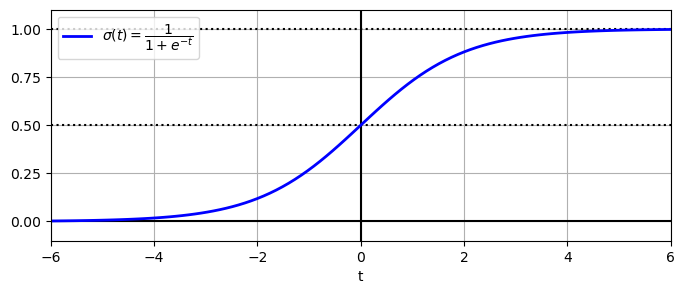

In [1]:
import numpy as np
import matplotlib.pyplot as plt

lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 3))
plt.plot([-lim, lim], [0, 0], "k-")
plt.plot([-lim, lim], [0.5, 0.5], "k:")
plt.plot([-lim, lim], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \dfrac{1}{1 + e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left")
plt.axis([-lim, lim, -0.1, 1.1])
plt.gca().set_yticks([0, 0.25, 0.5, 0.75, 1])
plt.grid()
plt.show()

### Equation 3: Logistic Regression model prediction using a 50% threshold probability

$$\hat{y} = \begin{cases} 0 & \text{if } \hat{p} < 0.5 \\ 1 & \text{if } \hat{p} \geq 0.5 \end{cases}$$

`Note:` $\sigma (t) < 0.5$ when t<0 \
&   $\sigma (t) \geq 0.5$ when $t \geq 0$   \
So a logisti regression model using 50% threshold predicts 1 if ($\theta^{T}X \geq 0)$ and predicts 0 if ($\theta^{T}X < 0$)

## Training and Cost Function

Objective is to set the parameter vector $\theta$ so that the model estimates high probabilities for positive instances (y=1) and low probabilities for negative instances (y=0).

### Equation 4: Cost function of a single training instance

$$c(\theta) = \begin{cases} -\log(\hat{p}) & \text{if } y=1 \\ -\log(1-\hat{p}) & \text{if } y = 0 \end{cases}$$

This makes snese because -log(t) grows very large when t approaches 0, so the cost will be large if model estimates a probability close to 0 for a positive instance, and also it will be large if the model estimates a probability close to 1 for a negative instance.

The cost function over the whole training set is the average cost over all the training instances. \
It can be written in a single expression called the log loss.

### Equation 5: Logistic Regression cost function (log loss)

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m}[y^{(i)}\log(\hat{p}^{(i)}) + (1-y^{(i)})\log(1-\hat{p}^{(i)})]$$

`Bad News:` There is no known closed foem equation to compute the value of $\theta$ that minimises the cost function.

`Good News:` This cost function is `convex`, so gradient descent (or any other optimisation algorithm) is guranteed to find the global minimum.

The partial derivatives of the cost function with regard to he $j^{th}$ model parameter $\theta_j$ are given by:

### Equation 6: Logistic cost function partial derivatives:

$$\frac{\partial}{\partial \theta_j} \text{J}(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^{m} \left( \sigma\left(\boldsymbol{\theta}^{\intercal} \mathbf{x}^{(i)}\right) - y^{(i)} \right) x_j^{(i)}$$

After getting The gradient vector containing all he partial derivatives, we can use it in batch gradient descent algorithm.

---
This was the algorithm for Logistic Regression

---



## Decision Boundaries

Illustrating Logistic Regression using the famous iris dataset.

In [2]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [3]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
iris.target.head()      #note that the instances are not shuffeled

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

#### Using 1 feature (petal width):

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == "virginica"   #target is True for virginica, False for others
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Let's look at the model's estimated probabilities for flowers with petal widths varying from 0 cm to 3 cm:

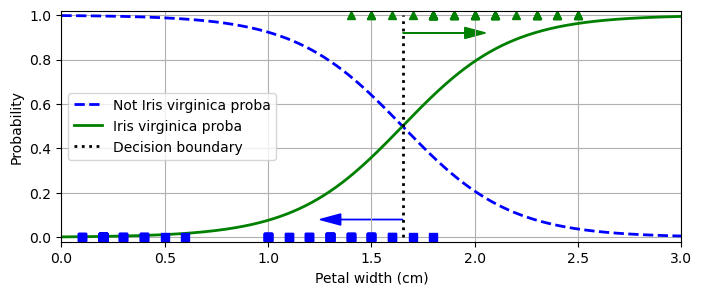

In [7]:
import numpy as np
import matplotlib.pyplot as plt

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2, label="Decision boundary")

# extra code – this section beautifies 
plt.arrow(x=decision_boundary, y=0.08, dx=-0.3, dy=0, head_width=0.05, head_length=0.1, fc="b", ec="b")
plt.arrow(x=decision_boundary, y=0.92, dx=0.3, dy=0, head_width=0.05, head_length=0.1, fc="g", ec="g")
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bs")
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "g^")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()

plt.show()

The petal width of Iris virginica flowers (represented by triangles) ranges from 1.4 cm
to 2.5 cm, while the other iris flowers (represented by squares) generally have a
smaller petal width, ranging from 0.1 cm to 1.8 cm. Notice that there is a bit of over
lap. Above about 2 cm the classifier is highly confident that the flower is an Iris virgin
ica (it outputs a high probability for that class), while below 1 cm it is highly
confident that it is not an Iris virginica (high probability for the “Not Iris virginica”class). In between these extremes, the classifier is unsure. However, if you ask it to predict the class (using the predict() method rather than the predict_proba()
method), it will return whichever class is the most likely. Therefore, there is a decision
boundary at around 1.6 cm where both probabilities are equal to 50%: if the petal
width is higher than 1.6 cm, the classifier will predict that the flower is an Iris virgin
ica, and otherwise it will predict that it is not (even if it is not very confident):

In [8]:
decision_boundary

np.float64(1.6516516516516517)

In [9]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])

#### Using 2 features:

The next figure shows the same dataset, but this time displaying two features: petal width
and length. Once trained, the Logistic Regression classifier can, based on these two
features, estimate the probability that a new flower is an Iris virginica. The dashed line
represents the points where the model estimates a 50% probability: this is the model’s
decision boundary. Note that it is a linear boundary. Each parallel line represents the
points where the model outputs a specific probability, from 15% (bottom left) to 90%
(top right). All the flowers beyond the top-right line have an over 90% chance of
being Iris virginica, according to the model

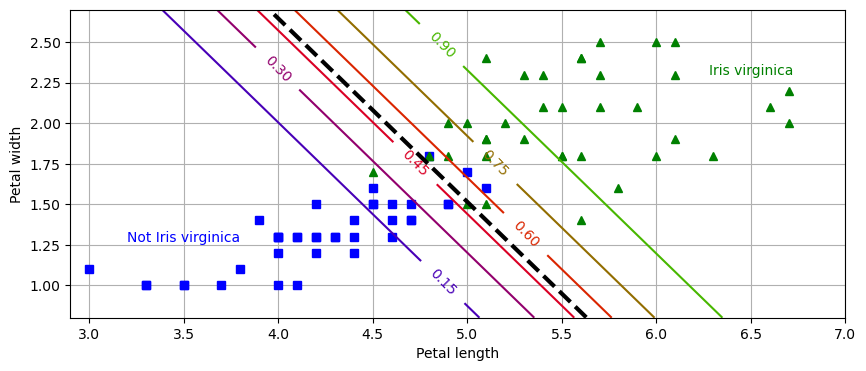

In [10]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(C=2, random_state=42)
log_reg.fit(X_train, y_train)

# for the contour plot
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1), np.linspace(0.8, 2.7, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
y_proba = log_reg.predict_proba(X_new)
zz = y_proba[:, 1].reshape(x0.shape)

# for the decision boundary
left_right = np.array([2.9, 7])
boundary = -((log_reg.coef_[0, 0] * left_right + log_reg.intercept_[0])/ log_reg.coef_[0, 1])

plt.figure(figsize=(10, 4))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], "bs")
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], "g^")
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)
plt.clabel(contour, inline=1)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.27, "Not Iris virginica", color="b", ha="center")
plt.text(6.5, 2.3, "Iris virginica", color="g", ha="center")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.axis([2.9, 7, 0.8, 2.7])
plt.grid()
plt.show()

---